<div class="colab-button-container">
  <a href="https://colab.research.google.com/drive/1aWvvRbfc861rWxBfv6F6spvri1d4YMda?usp=sharing"
     target="_blank"
     class="colab-top-button"
     title="Open this notebook in Google Colab">
    <img src="https://colab.research.google.com/assets/colab-badge.svg"
         alt="Open in Colab"
         class="colab-badge">
  </a>
</div>

---
format:
  html:
    page-layout: full
    mainfont: "Inter"
    toc: true
---

# An Introduction to Differential Expression Analysis of Bulk RNA-seq Data
#### Written by Maya Caskey (based off an older version by Delaney Sullivan)

This notebook provides a step-by-step guide to performing basic a bulk RNA-seq gene-level differential expression analysis using `kb-python` for quantification and [`edgeR`](https://www.bioconductor.org/packages/devel/bioc/vignettes/edgeR/inst/doc/edgeRUsersGuide.pdf) for downstream analysis.

## The Dataset
This notebook will analyze **human lung fibroblast data** from the paper: Differential analysis of gene regulation at transcript resolution with RNA-seq by Cole Trapnell, David G Henderickson, Martin Savageau, Loyal Goff, John L Rinn and Lior Pachter, *Nature Biotechnology* 31, 46–53 (2013).

In this analysis, we would like to quantify the difference in gene expression between unperturbed fibroblast cells (the control group) and fibroblast cells without the developmental transcritption factor HOX1A (the knockdown group). 

::: {.callout-note title="Bulk vs. Pseudobulk Analyses"}
This notebook demonstrates alignment and analysis of **bulk RNA-seq data**. However, differential expression analysis is also commonly performed on **pseudobulk data** derived from single-cell RNA-seq experiments. Single-cell RNA-seq provides the advantage of measuring gene expression at the resolution of individual cells, which allows cells to be classified by cell type or other biological properties. However, it is generally inappropriate to treat individual cells as independent biological replicates, since cells originating from the same sample share the same biological and technical sources of variation.

A pseudobulk analysis addresses this by grouping cells by cell type (or another annotation) within each sample and **aggregating their counts**. Differential expression analysis is then performed on these aggregated counts, treating each sample as the biological replicate. To learn more about preparing single-cell data for differential expression analysis, see our [scRNA-seq workflow](/notebooks/sc_workflow.ipynb). If you are performing a pseudobulk analysis and already have aggregated counts for each sample and cell type, you can skip directly to Step 3.
:::

## Initial Set-Up

### Install Required Packages

In [1]:
# Install the kb_python package
system("pip install kb_python")

In [ ]:
# Install R packages from Bioconductor
if (!require("BiocManager", quietly = TRUE))
    install.packages("BiocManager")
BiocManager::install("edgeR", ask=FALSE, quiet=TRUE)
BiocManager::install("rhdf5", ask=FALSE, quiet=TRUE)
BiocManager::install("tximport", ask=FALSE, quiet=TRUE)
BiocManager::install("EnhancedVolcano", ask=FALSE, quiet=TRUE)
install.packages("pheatmap")

### Download Data

::: {.callout-note}
For the convenience of this tutorial, the control and knockdown fibroblast samples are subsetted to 1 million reads each.
:::

In [3]:
## Download control group fastq files
system("wget -q https://github.com/pachterlab/data/releases/download/v1/C_1_R1.fastq.gz")
system("wget -q https://github.com/pachterlab/data/releases/download/v1/C_1_R2.fastq.gz")
system("wget -q https://github.com/pachterlab/data/releases/download/v1/C_2_R1.fastq.gz")
system("wget -q https://github.com/pachterlab/data/releases/download/v1/C_2_R2.fastq.gz")
system("wget -q https://github.com/pachterlab/data/releases/download/v1/C_3_R1.fastq.gz")
system("wget -q https://github.com/pachterlab/data/releases/download/v1/C_3_R2.fastq.gz")

In [4]:
# Download knockdown group fastq files
system("wget -q https://github.com/pachterlab/data/releases/download/v1/KD_1_R1.fastq.gz")
system("wget -q https://github.com/pachterlab/data/releases/download/v1/KD_1_R2.fastq.gz")
system("wget -q https://github.com/pachterlab/data/releases/download/v1/KD_2_R1.fastq.gz")
system("wget -q https://github.com/pachterlab/data/releases/download/v1/KD_2_R2.fastq.gz")
system("wget -q https://github.com/pachterlab/data/releases/download/v1/KD_3_R1.fastq.gz")
system("wget -q https://github.com/pachterlab/data/releases/download/v1/KD_3_R2.fastq.gz")

## Step 1: Read Pseudoalignment

### Build a Custom Genome Index with `kb ref`

In [5]:
system("kb ref -i index.idx -g t2g.txt -f1 cdna.fasta Homo_sapiens.GRCh38.dna.primary_assembly.fa.gz Homo_sapiens.GRCh38.115.gtf.gz")

### Pseudoalign Reads to Reference with `kb count`

**`kallisto` Quantification**

For bulk reads, kallisto does not produce raw read counts the way alignment-based RNA-seq pipelines do. Instead, it uses a probabilistic model of **pseudoalignment** to estimate **transcript abundances**. For each read $r$, kallisto determines the set of transcripts $T_r$ with which it is compatible and assigns abundance parameters $\lambda_t$ by maximizing the likelihood:

$$L(\lambda \mid \text{reads}) = \prod_{r=1}^{N} \left( \sum_{t \in T_r} \frac{\lambda_t}{l_t}\right),$$

The raw abundance counts are useful for isoform-level analyses, but as we are performing a gene-level differential expression analysis, they are unnecessary. Still, kallisto provides fast quantification of transcript abundances which can then be converted to a gene-level count matrix with the `tximport` library.

**Pseudoalignment with `kb count`**

For the input to `kb count`, we supply all FASTQ files to the command-line. The order in which the files are supplied determines the sample identities after read quantification.

In [ ]:
cmd <- paste("kb count", 
  "-x BULK",
  "-i index.idx",
  "-g t2g.txt",
  "--parity paired",
  "-o kb_out",
  "-t 2",
  "--tcc",
  "--matrix-to-directories",
  "C_1_R1.fastq.gz C_1_R2.fastq.gz",
  "C_2_R1.fastq.gz C_2_R2.fastq.gz",
  "C_3_R1.fastq.gz C_3_R2.fastq.gz",
  "KD_1_R1.fastq.gz KD_1_R2.fastq.gz",
  "KD_2_R1.fastq.gz KD_2_R2.fastq.gz",
  "KD_3_R1.fastq.gz KD_3_R2.fastq.gz")

system(cmd)


**Inspect the Output**

The `--matrix-to-directories` option instructs `kb count` to store the results of each sample in a separate directory. The numbers correspond to the order in which we supplied the FASTQ files to the `kb count` command.

In [8]:
system("ls kb_out/quant_unfiltered")

## Step 2: Convert Abundances to Gene Counts with `tximport`

Regardless of the resolution (i.e. gene-level, isoform-level), most differential expression tools expect count data as input. Because we are not performing an isoform-level analysis, we use the tximport package to summarize the transcript-level abundance estimates produced by kallisto into gene-level counts. When aggregating transcripts belonging to the same gene, tximport accounts for differences in transcript length, which influence how many sequencing fragments are expected to originate from each transcript. Without correcting for transcript length, genes with longer transcripts could appear to be more highly expressed simply because they generate more fragments.

In [ ]:
library(tximport)

# Vector of kallisto abundance files 
files <- c(
    # Control samples
    "kb_out/quant_unfiltered/abundance_1/abundance.h5",
    "kb_out/quant_unfiltered/abundance_2/abundance.h5",
    "kb_out/quant_unfiltered/abundance_3/abundance.h5",
    # Knockdown samples
    "kb_out/quant_unfiltered/abundance_4/abundance.h5",
    "kb_out/quant_unfiltered/abundance_5/abundance.h5",
    "kb_out/quant_unfiltered/abundance_6/abundance.h5"
)

# tx2gene dataframe with columns: TXNAME, GENEID
tx2gene <- read.table("t2g.txt", header=FALSE, sep="\t")
tx2gene <- tx2gene[, c("V1", "V2", "V3")]
colnames(tx2gene) <- c("TXNAME", "GENEID", "GENENAME")

# Import kallisto abundance files and summarize to gene level
txi <- tximport(files, type="kallisto", tx2gene=tx2gene, countsFromAbundance="lengthScaledTPM")


In [10]:
# Replace gene IDs with gene names in the txi counts matrix for better interpretability
gene_annot <- unique(tx2gene[, c("GENEID", "GENENAME")])
gene_annot <- gene_annot[match(rownames(txi$counts), gene_annot$GENEID), ]
rownames(txi$counts) <- gene_annot$GENENAME

## A Brief Intro to Differential Expression Analysis
To identify differentially expressed genes, we first need a statistical model to simulate how RNA-seq counts are measured and how they vary between biological replicates. Most modern differential expression tools (such as edgeR and DESeq2) follow the same basic strategy, which we summarize below.

### The Negative Binomial Model for Count Data

RNA-seq experiments produce count data: for each gene, we observe the number of sequencing fragments that originate from that gene in each sample.

A natural starting point for modeling count data is the **Poisson distribution**, which describes the probability of observing a number of events in a fixed sampling process. Under a Poisson model, the probability of observing $n$ counts for a gene is:

$$p(n)=\frac{\lambda^n e^{-\lambda}}{n!}$$

where $\lambda=\mathbb{E}[n]$, the expected number of fragments originating from that gene.

A key property of the Poisson distribution is that the mean is equal to the variance:

$$\text{var}(n) = \mathbb{E}[n] = \lambda$$

However, RNA-seq data consistently show greater variability than predicted by a Poisson model, a phenomenon known as **overdispersion**. This extra variability arises from biological differences between replicates as well as additional technical noise. One hypothesis for why RNA-seq  is that the expression of RNA occurs in bursts and not continuously, leading to high variability in the number of RNA molecules present for a given gene at any one moment.

To account for this, differential expression methods typically use an extension of the Poisson model called the the **negative binomial model**, which allows for dispersion greater than the mean. Under the negative binomial model, the variance–mean relationship becomes:

$$\text{var}(n)=\mu + \phi\mu^2$$

where $\mu$ is the expected count for a gene, and $\phi$ is the dispersion parameter that captures variability beyond simple Poisson sampling noise.

Dividing both sides by $\mu^2$ gives the squared coefficient of variation:

$$\text{CV}^2(n) = 1/\mu + \phi.$$

Here $1/\mu$ represents the variation due to sampling and $\phi$ the variation due to both biological and technical variance. For this reason, $\sqrt{\phi}$ is often called the **biological coefficient of variation** (BCV).

### Fitting a Negative Binomial Generalized Linear Model
In differential expression analysis, we want to determine whether gene expression differs between experimental conditions while accounting for other variables such as batch effects, collection date, or cohort. These variables are called covariates.

A simple way to relate gene expression to covariates is linear regression, which models the relationship between an outcome $y$ and predictors $x$:

$$y=\beta x + \alpha$$

However, linear regression assumes that data are continuous, normally distributed, and able to take negative values. RNA-seq counts violate these assumptions because they are discrete, non-negative, and non-normaly distributed. Generalized linear models are an extension of the linear model. This class of models can simulate data from a variety of probability distributions. RNA-seq differential expression tools fit counts to a negative binomial GLM, which allows us to model count data while accounting for overdispersion. 

If you would like to learn more about what GLMs are and how they work, this [series of youtube videos](https://www.youtube.com/watch?v=6Nfv0Xr44y8&t=16s) provides a great overview.

::: {.callout-note title="The Design Matrix"}

In the previous section we described modeling gene expression using a regression model:

$$y = \beta x + \alpha$$

Here, $x$ represents the experimental variables (called covariates) that may influence gene expression, such as treatment condition or batch effects. The parameters $\beta$ describe how strongly each covariate affects expression.

In practice, experiments often include multiple samples and multiple covariates. To represent this information compactly, the covariates for all samples are organized into a design matrix.

Each row of the design matrix corresponds to a sample, and each column corresponds to a covariate included in the model. For example, suppose we have four samples collected under two conditions:

| Sample | Condition |
|--------|-----------|
| S1     | Control   |
| S2	 | Control   |
| S3     | Treatment |
| S4	 | Treatment |

The design matrix describing this experiment might look like:

$$X = \begin{bmatrix} 1 & 0 \\ 1 & 0 \\ 1 & 1 \\ 1 & 1 \end{bmatrix}$$

The first column represents the intercept (baseline expression), while the second column indicates whether a sample belongs to the treatment condition.

Using this matrix notation, the regression model can be written as:

$$y = X\beta$$

where:

- $X$ is the design matrix containing the covariates
- $\beta$ is a vector of coefficients describing the effect of each covariate

The generalized linear model used in RNA-seq differential expression analysis estimates these coefficients for each gene. Testing whether a gene is differentially expressed between conditions is equivalent to testing whether the coefficient corresponding to the treatment variable differs significantly from zero.

A well-designed experiment produces a design matrix in which covariates are not strongly confounded. For more information on designing experiments, see our [page on experimental design](/pages/design.qmd).
:::

### Testing for Differential Expression

After fitting the negative binomial GLM, we test whether the coefficient $\beta_i$ associated with the condition of interest $i$ differs significantly from zero.

In other words, we test whether the model provides evidence that expression changes between conditions beyond what would be expected from natural variability between replicates.

Several statistical tests can be used for this purpose, including:

- likelihood ratio tests
- Wald tests
- quasi-likelihood F-tests

The recommended edgeR workflow uses a **quasi-likelihood F-test**, which provides improved control of false positives when replicate numbers are small.

### Bringing It All Together

State-of-the-art differential expression tools such as edgeR and DESeq2 follow the same general strategy:

1. Estimate the dispersion (biological coefficient of variation) for each gene.
2. Fit a negative binomial generalized linear model relating gene expression to experimental covariates.
3. Use statistical tests to determine whether expression differs significantly between conditions.

This framework allows RNA-seq experiments to identify genes whose expression changes reproducibly between biological conditions while accounting for natural variability between replicates.

## Step 3: Perform Differential Expression Analysis with `edgeR`

:::{.callout-note title="DEseq2"}
In this tutorial we use edgeR for differential expression analysis because it offers a flexible modeling framework and is widely used for RNA-seq workflows. However, DESeq2 is another commonly used package for differential expression analysis, and the overall analysis strategy used by DESeq2 and edgeR is very similar. The goal of this tutorial is to provide a conceptual overview of differential expression analysis that applies regardless of the specific tool used. If you would like to perform the analysis using DESeq2 instead, you can refer to the official [DESeq2 vignette](https://bioconductor.org/packages/release/bioc/vignettes/DESeq2/inst/doc/DESeq2.html).
:::
:::

### The DGEList Object

Before we can perform analysis with edgeR, we must convert our data into a **DGEList object**, the built-in data class for edgeR. The DGEList object is where edgeR functions will store the results of preprocessing and inference as we move through our analysis.


A DGEList object is composed of rows corresponding to genomic features and columns to samples. It has the following basic components:

- `counts`: a numeric matrix of read counts, with one row for each gene and one column for each sample.
- `samples`: a dataframe with a row for each sample and two columns. The two columns, `lib.size` and `norm.factors`, contain the group labels, library sizes and normalization factors. Other columns can be optionally added to give more detailed sample information.

Other optional components include: 

- `genes`: a dataframe giving annotation information for each gene
- `AveLogCPM`: numeric vector giving average log2 counts per million for each gene.
- `common.dispersion`: numeric scalar giving the overall dispersion estimate.
- `trended.dispersion`: numeric vector giving trended dispersion estimates for each gene.
- `tagwise.dispersion`: numeric vector giving tagwise dispersion estimates for each gene.
- `offset`: numeric matrix of same size as counts giving offsets for use in log-linear models.



Below we construct a DGEList Object from the output of tximport and diplay a summary of the object with the DGEList `show()` method. This DGEList object will updated at each stage of our analyis.

In [11]:
# Create DGEList object for edgeR with condition labels
library(edgeR)
group <- factor(c("Control", "Control", "Control", "Knockdown", "Knockdown", "Knockdown"))
dge <- DGEList(counts=txi$counts, group=group)
show(dge) 

Loading required package: limma



An object of class "DGEList"
$counts
         Sample1   Sample2   Sample3   Sample4   Sample5   Sample6
TSPAN6 29.327378 27.899830 24.504316 63.169808 74.099052 62.209640
TNMD    0.000000  0.000000  0.000000  0.000000  0.000000  0.000000
DPM1   23.180411 32.170872 28.271868 29.662326 30.546453 32.881122
SCYL3   6.332179  9.240302 12.124077  4.246378  2.627401  5.787740
FIRRM   3.171245  9.965966  1.550624  3.868808  3.025909  4.986134
78894 more rows ...

$samples
            group lib.size norm.factors
Sample1   Control   936976            1
Sample2   Control   935416            1
Sample3   Control   930627            1
Sample4 Knockdown   923734            1
Sample5 Knockdown   931002            1
Sample6 Knockdown   931585            1



::: {.callout-note title="Loading in Pseudobulk Data"}
Say that you are performing a pseudobulk analysis and have already aggregated counts for each sample and cell type.To load in your pseudobulk data and metadata, you can use the `read.csv()` function to read in a count matrix from a CSV file. The count matrix should have genes as rows and samples as columns, with the first column containing gene names. You can then create a DGEList object from this count matrix using the `DGEList()function from edgeR, specifying the counts and sample information as needed.

For instance, if you have a count matrix in a file called `counts.csv` and a metadata file called `metadata.csv`, you could load the data and create a DGEList object as follows:

```R
counts <- read.csv("counts.csv", row.names=1)
metadata <- read.csv("metadata.csv", row.names=1)
dge <- DGEList(counts=counts, samples=metadata)
```
:::

### Gene Filtering and Normalization

**Gene Filtering with `filterByExpr()`**

Before normalizing the data with `calcNormFactors()`, it is standard practice in edgeR to remove genes that are not expressed at meaningful levels using `filterByExpr()`. Lowly expressed genes contribute little biological information but can add substantial noise to normalization and dispersion estimation. By applying `filterByExpr()` first, we restrict the dataset to genes that have sufficient counts in enough samples to be informative. This ensures that normalization is computed from genes with stable expression levels, improving both the accuracy of the scaling factors and the effectiveness of downstream differential expression analysis.

**What `calcNormFactors()` Does**

Normalization is a critical step in RNA-seq analysis because samples often differ in sequencing depth and RNA composition. Simply dividing by total library size is not always sufficient—if one sample is dominated by a handful of highly expressed genes, all other genes will appear artificially underexpressed. edgeR addresses this using **TMM (Trimmed Mean of M-values)** normalization, implemented in `calcNormFactors()`.
This adjustment allows for differences in sequencing depth and compositional bias to be corrected without altering the underlying counts themselves.

In short, filtering ensures that normalization is guided by meaningful gene expression patterns, and `calcNormFactors()` then computes scaling factors that place all samples on a comparable expression scale, enabling accurate differential expression testing.


In [12]:
# Identify genes with sufficient counts for statistical testing
keep <- filterByExpr(dge)

# Subset DGEList to keep only the filtered genes and recalculate library sizes
dge <- dge[keep, , keep.lib.sizes = FALSE]
dge <- calcNormFactors(dge)

show(dge)

An object of class "DGEList"
$counts
        Sample1  Sample2  Sample3  Sample4  Sample5  Sample6
TSPAN6 29.32738 27.89983 24.50432 63.16981 74.09905 62.20964
DPM1   23.18041 32.17087 28.27187 29.66233 30.54645 32.88112
CFH    21.34382 14.31429 22.35018 45.75896 21.68549 16.97011
FUCA2  78.65853 62.54470 79.69163 80.80183 79.68978 91.70360
GCLC   33.76694 17.02071 25.67429 75.49852 74.97687 48.85903
9195 more rows ...

$samples
            group lib.size norm.factors
Sample1   Control 916396.4    1.0047883
Sample2   Control 914588.8    0.9977529
Sample3   Control 910374.1    1.0096557
Sample4 Knockdown 904005.7    0.9991274
Sample5 Knockdown 911649.3    0.9936096
Sample6 Knockdown 911863.1    0.9951589



Displaying our DGEList object, we now see that the number of genes has been reduced from 78,894 to 9,191.

### Exploring Sample Relationships with `plotMDS()`

The `plotMDS()` function in edgeR creates a multidimensional scaling (MDS) plot that visualizes the overall similarity between samples based on their expression profiles. This plot allows you to identify clustering patterns, detect batch effects, and spot potential outliers.

The Multidimensional Scaling Plot (MDS) is a two-dimensional reduction of high-dimensional data that compresses the data according to **leading log-fold-change distances**. For each pair of samples, `plotMDS()` computes the largest gene-wise log-fold changes and uses the average of these as a distance measure. By default, the top 500 most variable genes contribute to this distance. `plotMDS()` then arranges the points in a manner that best represents the leading log-fold-change distances between samples.


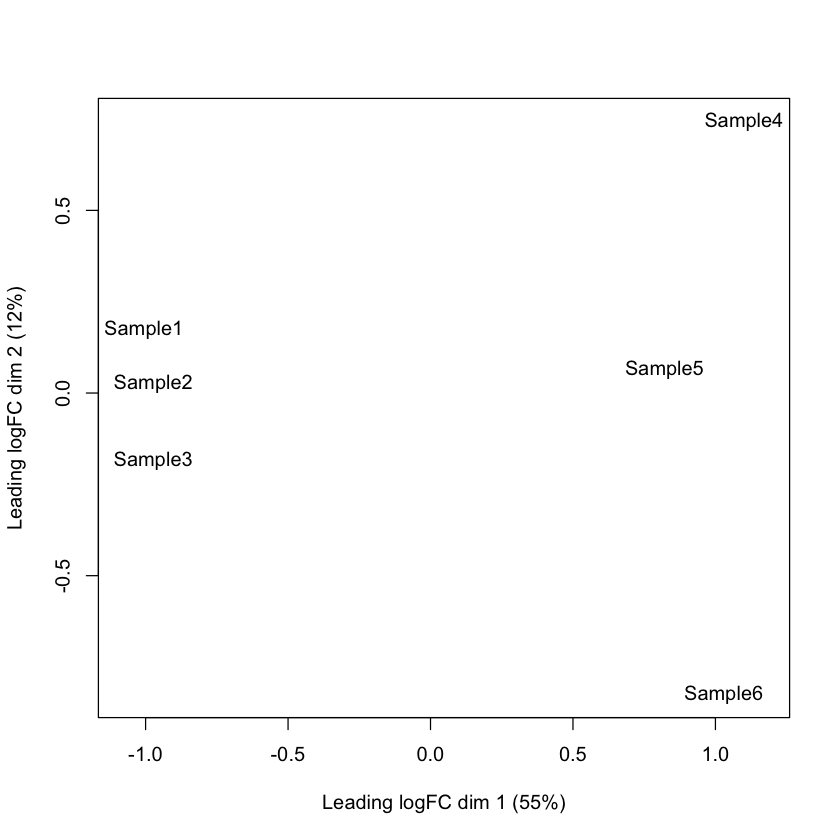

In [13]:
plotMDS(dge)

In this MDS plot, *dim 1* represents the greatest source of variation between samples, and *dim 2* represents the second greatest. Examining these dimensions helps you verify that biological groups cluster as expected and that no technical artifacts dominate the data. If unexpected clustering or outliers appear, this can signal issues such as batch effects or mislabeled samples that should be addressed before downstream analysis. Here we observe that *dim 1* represents the variation between the *control* and *knockdown* conditions.

### Build the Design Matrix

In practice, we do not construct the design matrix manually. Instead, we use R’s `model.matrix()` function, which generates the matrix automatically from a table of sample metadata. This metadata table typically contains one row per sample and columns describing experimental covariates such as treatment condition, batch, or organism cohort. The `model.matrix()` function takes a model formula that specifies which covariates should be included in the model and how they relate to the response variable. Below, the formula `~ group` indicates that we want to model gene expression as a function of the experimental condition. `model.matrix()` then converts this formula and the metadata table into the numeric matrix required by the generalized linear model, including automatically encoding categorical variables as indicator variables and adding an intercept term representing baseline expression.

We will often want to include additional covariates in the design matrix to account for batch effects or other sources of variation. For example, if we had information about the date on which each sample was collected, we could include this as a covariate in the design matrix to control for potential batch effects related to collection date. This would be done by adding the covariate to the metadata table and including it in the model formula passed to `model.matrix()`, for example: `~ group + collection_date`.

In [14]:
design <- model.matrix(~group, data = dge$samples)
colnames(design) <- gsub('group','',colnames(design))
design

,(Intercept),Knockdown
Sample1,1,0
Sample2,1,0
Sample3,1,0
Sample4,1,1
Sample5,1,1
Sample6,1,1


### Estimate Genewise Dispersion

Next, we estimate the overdisperion parameter (aka the squared biological coefficient of variation (BCV)) $\phi$ for each gene with `estimateDisp()`. Recall that the BCV is the square root of the dispersion parameter and reflects the expected variability in gene expression between biological replicates. EdgeR uses a method called **empirical Bayes shrinakge** to estimate $\phi$.

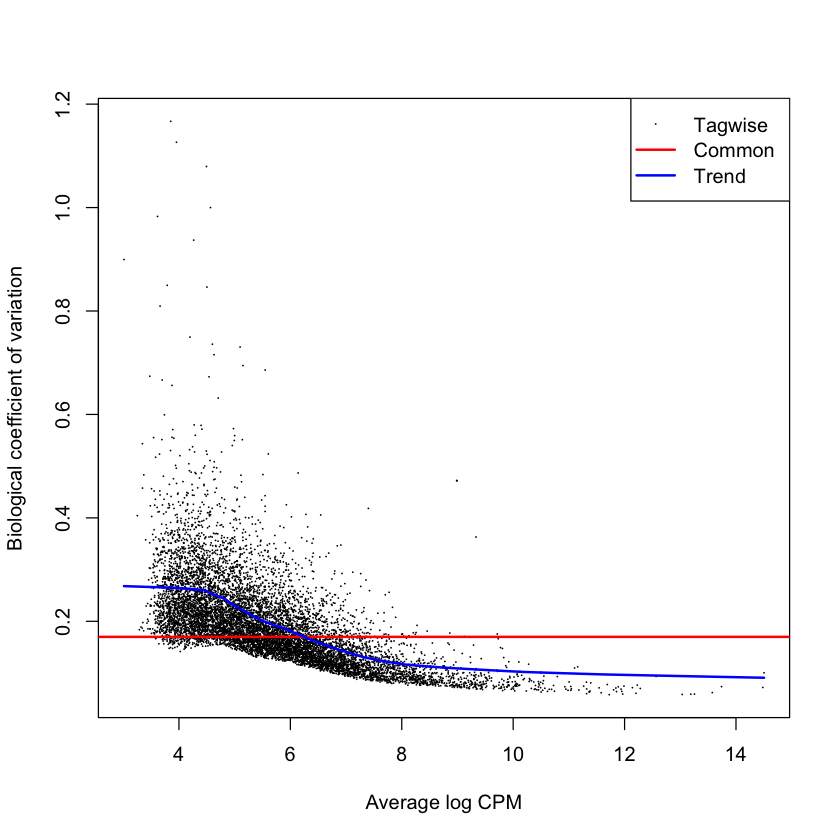

In [15]:
dge <- estimateDisp(dge,design)
plotBCV(dge)

The above plot, generated by `plotBCV()`, visualizes the **estimated BCV** ($\sqrt{\phi}$) for each gene. In this plot, each point represents a gene, with the average expression level on the x-axis and the estimated BCV on the y-axis. Genes with low expression typically show higher variability, while more highly expressed genes tend to have more stable expression levels. The red curve shows the overall trend used by edgeR to stabilize dispersion estimates across genes, which helps produce more reliable differential expression results, especially when the number of replicates is small.

In a typical BCV plot, most genes should cluster around the fitted trend line, with greater variability at low expression levels and lower variability for highly expressed genes. Extremely large BCV values or widespread scatter may indicate problems such as poor sample quality, strong batch effects, or insufficient biological replication.

### Fit the Negative Binomial GLM

The `glmQLFit()` function fits our data to a quasi-likelihood negative binomial GLM.

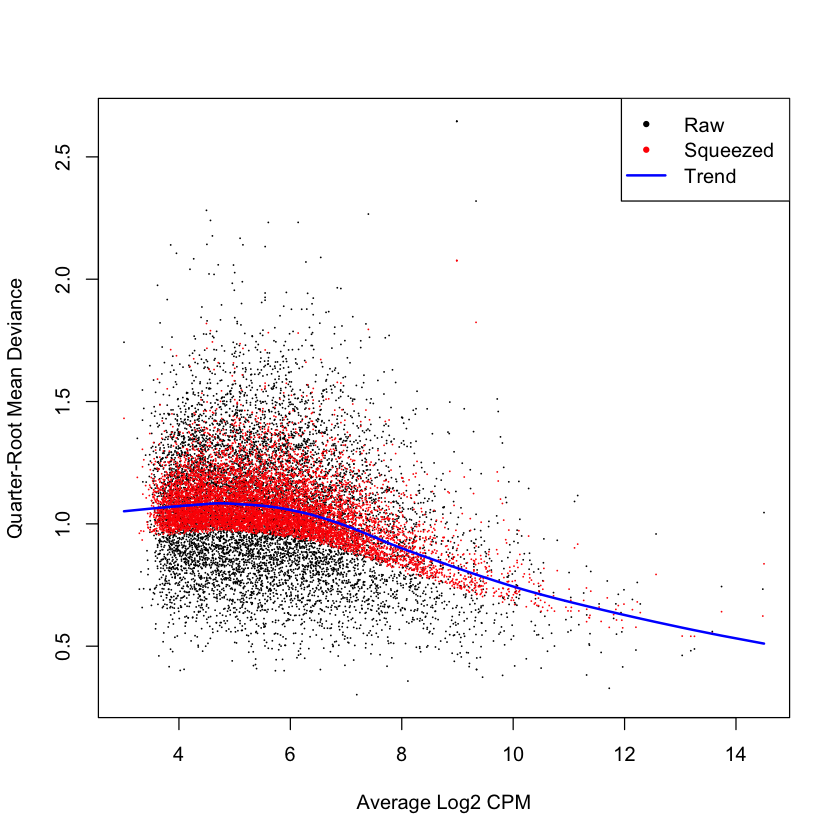

In [16]:
fit <- glmQLFit(dge,design)
plotQLDisp(fit)

The `plotQLDisp()` function visualizes the **quasi-likelihood dispersions** estimated during the `glmQLFit()` step of the edgeR workflow. While the BCV plot shows the biological variability between samples, the quasi-likelihood dispersion measures how well the fitted generalized linear model explains the counts for each gene. In this plot, each point represents a gene, with average expression on the x-axis and quasi-likelihood dispersion on the y-axis. The black points show the raw dispersion estimates calculated independently for each gene. Because these estimates can be noisy—especially when the number of replicates is small—edgeR adjusts them by borrowing information across all genes. The red points show these stabilized dispersion estimates after this adjustment. The blue curve shows the overall trend used to guide this process. These moderated dispersions are then used by the quasi-likelihood F-test to produce more reliable differential expression results.

### Identify Differentially Expressed Genes with the Quasi-Likelihood F-Test

We test for differential expression using edgeR’s `glmQLFTest()` function, which performs a **quasi-likelihood F-test**. This test compares the fitted model to a reduced model that excludes the condition of interest, asking whether including the condition significantly improves the model’s ability to explain the observed counts. Intuitively, it assesses whether the observed log fold changes between conditions are larger than would be expected given the estimated variability between biological replicates.

Because thousands of genes are tested simultaneously, some will appear significant purely by chance. To account for this, differential expression tools adjust p-values to control the false discovery rate (FDR), which estimates the expected proportion of false positives among the genes identified as significant. By applying a threshold to the FDR (commonly 0.05), we can identify genes whose expression differs between conditions while controlling the expected rate of false discoveries.

In [17]:
# Test for differential expression between Knockdown and Control
qlf <- glmQLFTest(fit) 

**The Mean-Difference Plot**

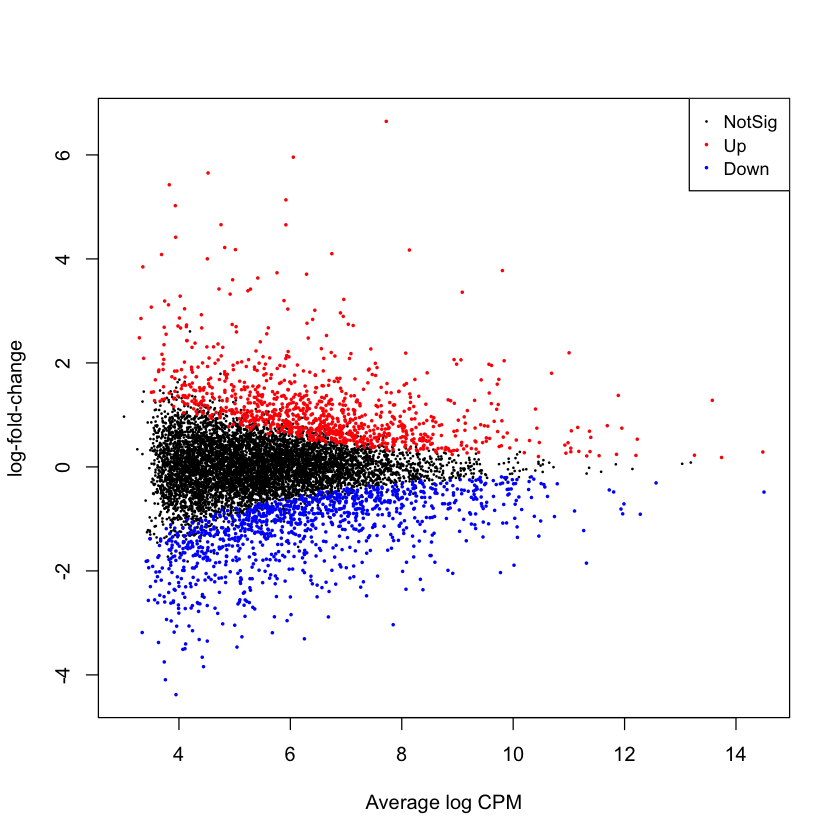

In [18]:
# Identify differentially expressed genes at FDR < 0.05
is.de <- decideTests(qlf)
# Generate the MD plot with DE genes highlighted
plotMD(qlf, status = is.de, col = c("red","blue"), main="", cex=0.4)

The above plot, the **MD plot (mean–difference plot)**, visualizes the relationship between the average expression level of each gene and the estimated change in expression between conditions. In this plot, each point represents a gene. The x-axis shows the **average log expression level** across samples, while the y-axis shows the **log fold change (logFC)** between the conditions being compared. Genes near zero on the y-axis have similar expression in both conditions, while genes farther from zero show larger differences in expression. Genes that are identified as significantly differentially expressed are typically highlighted in a different color. The MD plot provides a quick visual summary of how expression changes are distributed across genes and helps identify whether large fold changes occur primarily among low or highly expressed genes. The plot should appear as a funnel, with log-fold change decreasing with higher CPM.

**The Volcano Plot**

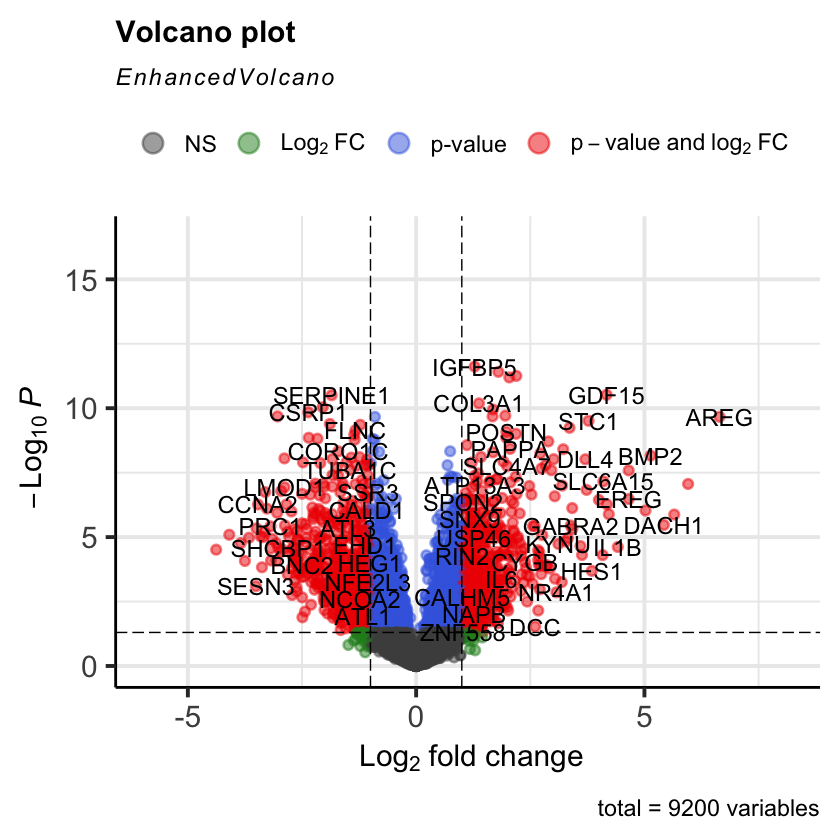

In [23]:
library(EnhancedVolcano)
library(ggplot2)
library(ggrepel)

# Rank genes by p-value and log fold change for volcano plot
res <- topTags(qlf, n=Inf)$table 

# Create volcano plot using EnhancedVolcano
EnhancedVolcano(
    res,
    lab = rownames(res),
    x = 'logFC',
    y = 'PValue',
    pCutoff = 0.05,
    FCcutoff = 1.0)

Above we show the **volcano plot**, which provides a visual summary of both the magnitude and statistical significance of differential expression results. In this plot, each point represents a gene. The x-axis shows the **log fold change (logFC)** between the conditions being compared, while the y-axis shows the negative **log-transformed p-value**, which reflects the statistical significance of the observed change. Genes with large expression changes appear farther from zero on the x-axis, while genes with stronger statistical support appear higher on the y-axis. As a result, genes that are both strongly differentially expressed and highly significant appear toward the upper left and upper right corners of the plot. Volcano plots are useful for quickly identifying genes with both large effect sizes and strong statistical evidence for differential expression.

**The Heatmap**

Another useful visualization is a heatmap showing the relative expression of the most significantly differentially expressed genes across samples. Each column represents a sample and each row represents a gene, with colors indicating relative expression levels. Ideally, we expect to see similar expression patterns among samples within the same condition and clear differences between the control and knockdown groups. Such clustering provides a visual confirmation that the differential expression results reflect consistent biological differences rather than random variation between samples.

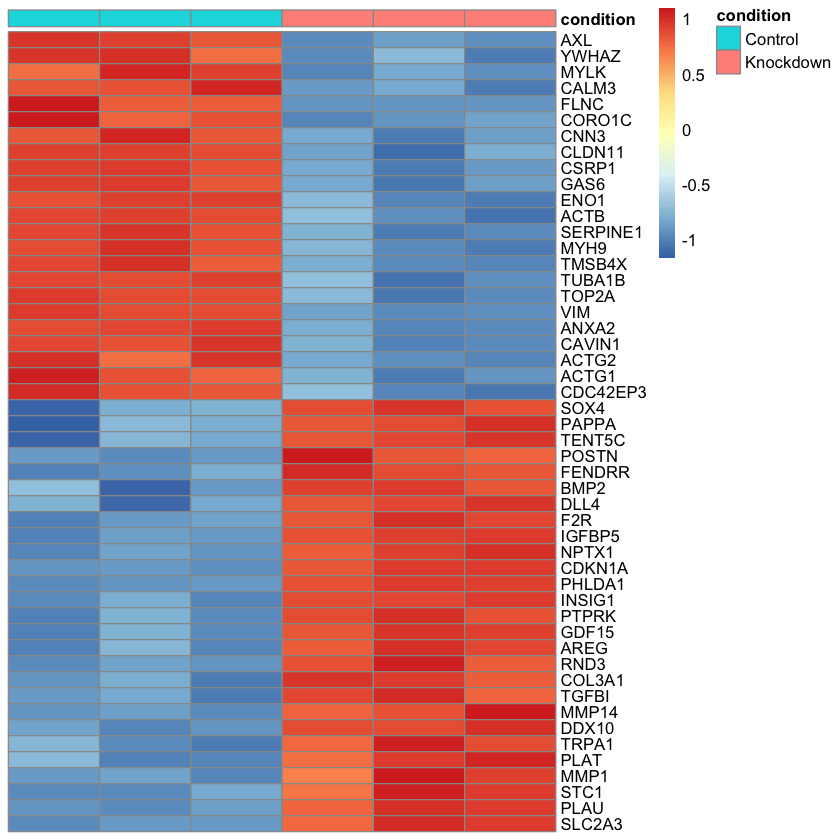

In [21]:
library(pheatmap)

# Pick top 50 DE genes for heatmap visualization
topGenes <- rownames(res)[res$FDR < 0.05]
topGenes <- topGenes[order(res[topGenes, "FDR"])][1:50]

ann <- data.frame(condition=group)
rownames(ann) <- c('Sample1', 'Sample2', 'Sample3', 'Sample4', 'Sample5', 'Sample6')
logcpm <- cpm(dge, log=TRUE, prior.count=1)
mat <- logcpm[topGenes, ]
mat <- t(scale(t(mat)))   # z-score by gene

pheatmap(mat,
         annotation_col = ann,
         show_colnames = FALSE,
         show_rownames = TRUE,
         treeheight_row = 0,
         treeheight_col = 0)


**Viewing the Data for Each Gene**

To simply view the statistics for each gene, we can display the `qlf$table` dataframe.

In [22]:
head(qlf$table)

,logFC,logCPM,F,PValue
,<dbl>,<dbl>,<dbl>,<dbl>
TSPAN6,1.3022909,5.746785,39.3951172,6.810824e-05
DPM1,0.1727986,5.109152,0.5044218,4.927505e-01
CFH,0.5576420,4.820311,1.9638381,1.894393e-01
FUCA2,0.2100170,6.471080,1.5777062,2.358128e-01
GCLC,1.3974112,5.719971,24.6137621,4.645058e-04
NFYA,0.2251651,5.767810,0.8504602,3.767409e-01
